<a href="https://colab.research.google.com/github/ronniedebojit2002-netizen/Data-Intelligence-System/blob/main/Part1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied AI & ML Capstone Project

# Part 1: Data Cleaning and Exploratory Data Analysis

**Dataset:** Ames Housing Dataset

**Student:** Debojit Lahiri

---

## Objective

The objective of this notebook is to clean, explore, and understand the Ames Housing dataset before building machine learning models. This includes handling missing values, detecting duplicates, analyzing feature distributions, identifying outliers, computing correlations, and producing visualizations that guide future modeling.

In [1]:
# Part 1 - Data Cleaning and Exploratory Data Analysis
# Applied AI & ML Capstone Project

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
housing_df = pd.read_csv("train.csv")

In [3]:
print("Shape of Dataset:")
print(housing_df.shape)

print("\nFirst Five Rows")
display(housing_df.head())

print("\nData Types")
display(housing_df.dtypes)

print("\nBasic Information")
housing_df.info()

Shape of Dataset:
(1460, 81)

First Five Rows


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Data Types


,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
Alley,object
LotShape,object
LandContour,object
Utilities,object



Basic Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   in

## 2. Null Value Analysis

Missing values can reduce the quality of machine learning models if not handled properly. In this section, we calculate both the count and percentage of missing values for every column. Columns with more than 20% missing values are identified separately because they may require special treatment or removal in later stages.

In [4]:
# Calculate missing value count and percentage
missing_count = housing_df.isnull().sum()

missing_percentage = (housing_df.isnull().sum() / housing_df.shape[0]) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns that have missing values
missing_table = missing_table[missing_table["Missing Count"] > 0]

# Sort by percentage
missing_table = missing_table.sort_values(by="Missing Percentage", ascending=False)

missing_table

,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [5]:
high_missing = missing_table[missing_table["Missing Percentage"] > 20]

print("Columns with more than 20% missing values:")
high_missing

Columns with more than 20% missing values:


,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274


In [6]:
low_missing = missing_table[missing_table["Missing Percentage"] <= 20]

print("Columns with 20% or less missing values:")
low_missing

Columns with 20% or less missing values:


,Missing Count,Missing Percentage
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945
GarageQual,81,5.547945
GarageCond,81,5.547945
BsmtExposure,38,2.602740
BsmtFinType2,38,2.602740
BsmtQual,37,2.534247
BsmtCond,37,2.534247


In [7]:
cleaned_df = housing_df.copy()

In [8]:
# Numerical columns
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if cleaned_df[col].isnull().sum() > 0:
        missing_pct = (cleaned_df[col].isnull().sum() / len(cleaned_df)) * 100

        if missing_pct <= 20:
            cleaned_df[col].fillna(cleaned_df[col].median(), inplace=True)

In [9]:
remaining_missing = cleaned_df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

remaining_missing.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
GarageFinish,81
GarageQual,81
GarageType,81
GarageCond,81


In [12]:
# Check if any numeric columns still have missing values
numeric_missing_after = cleaned_df.select_dtypes(include=['int64', 'float64']).isnull().sum()

numeric_missing_after = numeric_missing_after[numeric_missing_after > 0]

print("Numeric columns with remaining missing values:")
print(numeric_missing_after)

Numeric columns with remaining missing values:
Series([], dtype: int64)


## 3. Duplicate Detection and Removal

Duplicate rows can introduce bias and affect statistical analysis. In this section, duplicate records are identified and removed. The effect of duplicate removal on missing values is also examined.

In [13]:
# Count duplicate rows
duplicate_count = cleaned_df.duplicated().sum()

print(f"Number of duplicate rows before removal: {duplicate_count}")

Number of duplicate rows before removal: 0


In [14]:
# Remove duplicates
rows_before = cleaned_df.shape[0]

cleaned_df = cleaned_df.drop_duplicates()

rows_after = cleaned_df.shape[0]

print(f"Rows removed: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after}")

Rows removed: 0
Rows remaining: 1460


In [15]:
# Check whether duplicate removal changed null percentages
new_missing_percentage = (cleaned_df.isnull().sum() / cleaned_df.shape[0]) * 100

new_missing_percentage[new_missing_percentage > 0].sort_values(ascending=False)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
GarageFinish,5.547945
GarageQual,5.547945
GarageType,5.547945
GarageCond,5.547945


## 4. Data Type Correction

This section examines the data types of the dataset. The Ames Housing dataset already has appropriate inferred data types for its numerical variables. To optimize memory usage, repetitive string (object) columns are converted to the `category` data type. Memory usage is compared before and after the conversion.

In [16]:
# Memory usage before conversion
memory_before = cleaned_df.memory_usage(deep=True).sum()

print(f"Memory before conversion: {memory_before / (1024**2):.2f} MB")

Memory before conversion: 3.43 MB


In [17]:
# Display object columns
object_columns = cleaned_df.select_dtypes(include=['object']).columns

print("Object columns:")
print(list(object_columns))

Object columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [18]:
# Create a copy for datatype optimization
optimized_df = cleaned_df.copy()

for col in object_columns:
    optimized_df[col] = optimized_df[col].astype('category')

In [19]:
memory_after = optimized_df.memory_usage(deep=True).sum()

print(f"Memory after conversion : {memory_after / (1024**2):.2f} MB")

print(f"Memory saved : {(memory_before-memory_after)/(1024**2):.2f} MB")

Memory after conversion : 0.50 MB
Memory saved : 2.93 MB


In [20]:
optimized_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1460 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  OverallQual    1460 non-null   in

In [21]:
cleaned_df = optimized_df.copy()

## 5. Descriptive Statistics and Skewness Analysis

Descriptive statistics summarize the central tendency, spread, and distribution of the numerical features. Skewness is computed for every numerical column to identify variables with asymmetric distributions. Highly skewed features may require special treatment during preprocessing because the mean becomes less representative of the data than the median.

In [22]:
# Descriptive statistics for all numerical columns
cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1460.0,69.863699,22.027677,21.0,60.00,69.0,79.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1460.0,103.117123,180.731373,0.0,0.00,0.0,164.25,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [23]:
# Compute skewness of all numeric columns
numeric_columns = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

skewness = cleaned_df[numeric_columns].skew()

skewness = skewness.sort_values(key=abs, ascending=False)

skewness

,0
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
KitchenAbvGr,4.488397
BsmtFinSF2,4.255261
ScreenPorch,4.122214
BsmtHalfBath,4.103403
EnclosedPorch,3.089872


In [24]:
most_skewed_column = skewness.index[0]

print("Most Skewed Column:", most_skewed_column)
print("Skewness Value:", skewness.iloc[0])

Most Skewed Column: MiscVal
Skewness Value: 24.476794188821916


In [25]:
if skewness.iloc[0] > 0:
    print("The distribution is positively skewed (right-skewed).")
else:
    print("The distribution is negatively skewed (left-skewed).")

The distribution is positively skewed (right-skewed).


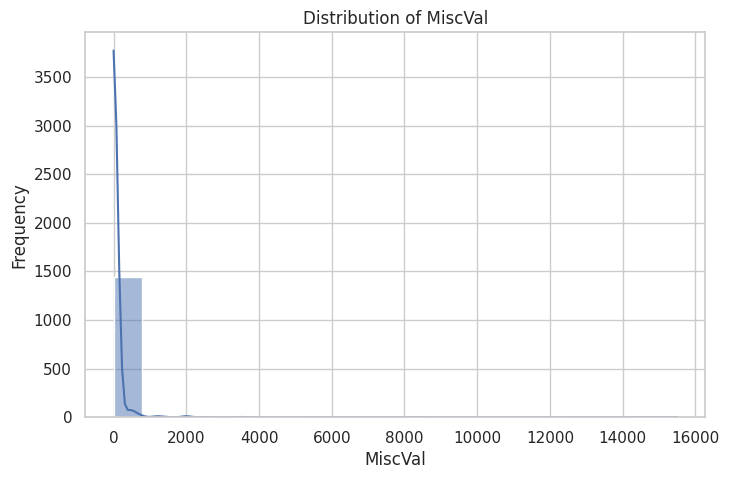

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(cleaned_df[most_skewed_column], bins=20, kde=True)

plt.title(f"Distribution of {most_skewed_column}")
plt.xlabel(most_skewed_column)
plt.ylabel("Frequency")

plt.show()

## 6. Outlier Detection using the Interquartile Range (IQR)

Outliers are identified using the Interquartile Range (IQR) method. Outliers are not removed at this stage because they may represent valid observations in the housing market. Their treatment will be considered during model development in Part 2.

In [27]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers

In [28]:
saleprice_outliers = detect_outliers_iqr(cleaned_df, "SalePrice")


Column: SalePrice
Q1: 129975.0
Q3: 214000.0
IQR: 84025.0
Lower Bound: 3937.5
Upper Bound: 340037.5
Number of Outliers: 61


In [29]:
grlivarea_outliers = detect_outliers_iqr(cleaned_df, "GrLivArea")


Column: GrLivArea
Q1: 1129.5
Q3: 1776.75
IQR: 647.25
Lower Bound: 158.625
Upper Bound: 2747.625
Number of Outliers: 31


In [30]:
saleprice_outliers.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
11,12,60,RL,85.0,11924,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,2Story,9,5,2005,2006,Hip,CompShg,WdShing,Wd Shng,Stone,286.0,Ex,TA,PConc,Ex,TA,No,GLQ,998,Unf,0,177,1175,GasA,Ex,Y,SBrkr,1182,1142,0,2324,1,0,3,0,4,1,Ex,11,Typ,2,Gd,BuiltIn,2005.0,Fin,3,736,TA,TA,Y,147,21,0,0,0,0,NaN,NaN,NaN,0,7,2006,New,Partial,345000
53,54,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,Inside,Gtl,Veenker,Norm,Norm,1Fam,1Story,9,5,1981,1987,Gable,WdShngl,WdShing,Wd Shng,NaN,0.0,Gd,TA,CBlock,Ex,TA,Gd,GLQ,1810,Unf,0,32,1842,GasA,Gd,Y,SBrkr,1842,0,0,1842,2,0,0,1,0,1,Gd,5,Typ,1,Gd,Attchd,1981.0,Fin,3,894,TA,TA,Y,857,72,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,CulDSac,Gtl,StoneBr,Norm,Norm,1Fam,2Story,10,5,2006,2006,Hip,CompShg,VinylSd,VinylSd,BrkFace,1031.0,Ex,TA,PConc,Ex,TA,Gd,Unf,0,Unf,0,1410,1410,GasA,Ex,Y,SBrkr,1426,1519,0,2945,0,0,3,1,3,1,Gd,10,Typ,1,Gd,BuiltIn,2006.0,Fin,3,641,TA,TA,Y,192,0,37,0,0,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
112,113,60,RL,77.0,9965,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2007,2007,Gable,CompShg,VinylSd,VinylSd,Stone,220.0,Gd,TA,PConc,Ex,TA,Av,GLQ,984,Unf,0,280,1264,GasA,Ex,Y,SBrkr,1282,1414,0,2696,1,0,2,1,4,1,Ex,10,Typ,1,Gd,BuiltIn,2007.0,Fin,3,792,TA,TA,Y,120,184,0,0,168,0,NaN,NaN,NaN,0,10,2007,New,Partial,383970
151,152,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2008,Hip,CompShg,VinylSd,VinylSd,Stone,436.0,Gd,TA,PConc,Ex,TA,Gd,GLQ,1400,Unf,0,310,1710,GasA,Ex,Y,SBrkr,1710,0,0,1710,1,0,2,0,2,1,Gd,6,Typ,1,Gd,Attchd,2007.0,RFn,3,866,TA,TA,Y,0,102,0,0,0,0,NaN,NaN,NaN,0,1,2008,New,Partial,372402


In [31]:
grlivarea_outliers.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,CulDSac,Gtl,StoneBr,Norm,Norm,1Fam,2Story,10,5,2006,2006,Hip,CompShg,VinylSd,VinylSd,BrkFace,1031.0,Ex,TA,PConc,Ex,TA,Gd,Unf,0,Unf,0,1410,1410,GasA,Ex,Y,SBrkr,1426,1519,0,2945,0,0,3,1,3,1,Gd,10,Typ,1,Gd,BuiltIn,2006.0,Fin,3,641,TA,TA,Y,192,0,37,0,0,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
118,119,60,RL,90.0,12376,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SawyerW,Norm,Norm,1Fam,2Story,7,5,1990,1990,Hip,CompShg,Plywood,Plywood,NaN,0.0,TA,TA,PConc,Gd,TA,Mn,GLQ,1470,Unf,0,203,1673,GasA,Gd,Y,SBrkr,1699,1523,0,3222,1,0,3,0,5,1,Gd,11,Typ,2,TA,Attchd,1990.0,Unf,3,594,TA,TA,Y,367,0,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,320000
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,2.5Fin,10,9,1892,1993,Gable,WdShngl,Wd Sdng,Wd Sdng,NaN,0.0,Gd,Gd,BrkTil,TA,TA,Mn,Unf,0,Unf,0,1107,1107,GasA,Ex,Y,SBrkr,1518,1518,572,3608,0,0,2,1,4,1,Ex,12,Typ,2,TA,Detchd,1993.0,Unf,3,840,Ex,TA,Y,0,260,0,0,410,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Artery,Norm,1Fam,2Story,8,4,1918,1990,Gable,CompShg,Stucco,Stucco,NaN,0.0,Gd,Gd,PConc,TA,TA,No,GLQ,1036,LwQ,184,140,1360,GasA,Gd,Y,SBrkr,1360,1360,392,3112,1,1,2,0,4,1,Gd,8,Typ,1,Ex,Detchd,1918.0,Unf,2,795,TA,TA,Y,0,16,552,0,0,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000
231,232,60,RL,174.0,15138,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,1995,1996,Gable,CompShg,VinylSd,VinylSd,BrkFace,506.0,Gd,TA,PConc,Gd,TA,No,GLQ,689,Unf,0,773,1462,GasA,Ex,Y,SBrkr,1490,1304,0,2794,1,0,2,1,4,1,Ex,9,Typ,1,TA,Attchd,1995.0,Fin,3,810,TA,TA,Y,0,146,202,0,0,0,NaN,NaN,NaN,0,7,2009,WD,Normal,403000


## 7.1 Line Plot

A line plot is used to visualize the variation of SalePrice across the dataset.

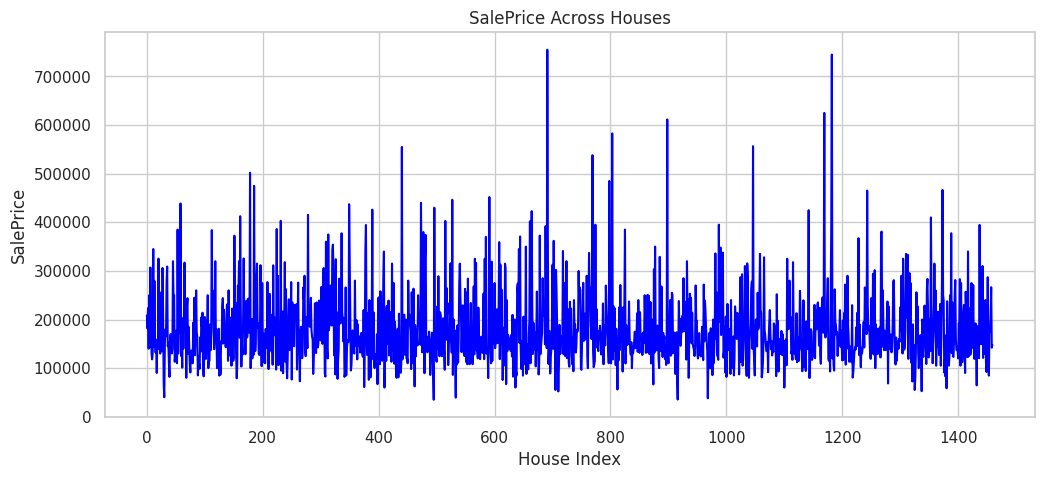

In [32]:
plt.figure(figsize=(12,5))

plt.plot(cleaned_df.index, cleaned_df["SalePrice"], color="blue")

plt.title("SalePrice Across Houses")
plt.xlabel("House Index")
plt.ylabel("SalePrice")

plt.show()

## 7.2 Bar Chart

Average SalePrice across different neighborhoods.

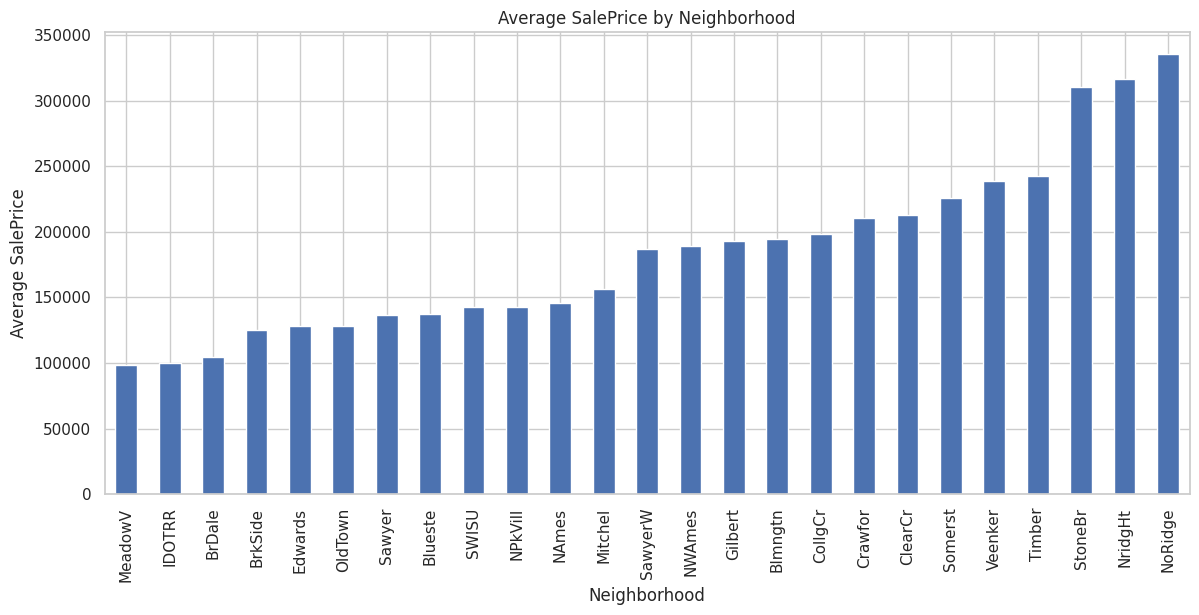

In [33]:
mean_price = cleaned_df.groupby("Neighborhood")["SalePrice"].mean().sort_values()

plt.figure(figsize=(14,6))

mean_price.plot(kind="bar")

plt.title("Average SalePrice by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average SalePrice")

plt.show()

## 7.3 Scatter Plot

Relationship between Ground Living Area and SalePrice.

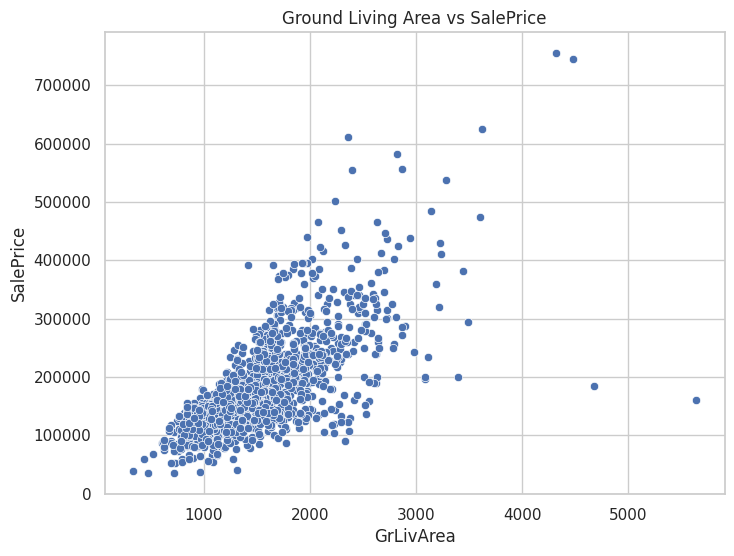

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cleaned_df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Ground Living Area vs SalePrice")

plt.show()

## 7.4 Box Plot

SalePrice distribution across Overall Quality categories.

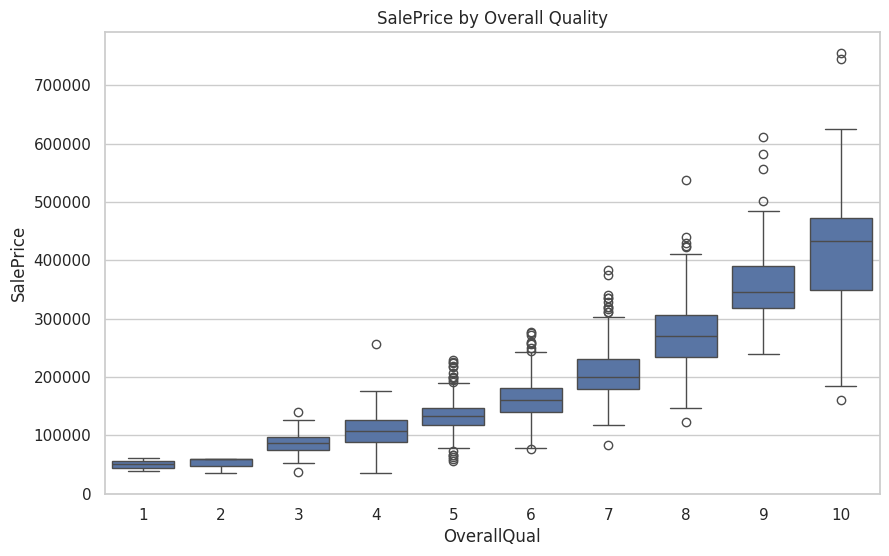

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=cleaned_df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("SalePrice by Overall Quality")

plt.show()

## 8. Correlation Heat Map

Correlation analysis is performed to understand the strength and direction of relationships between numerical variables. A Pearson correlation matrix is computed and visualized using a heat map. Highly correlated variables are identified for future feature selection.

In [36]:
# Pearson Correlation Matrix
pearson_corr = cleaned_df.select_dtypes(include=['int64', 'float64']).corr()

pearson_corr

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.009921,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.051071,-0.005024,-0.005968,-0.007940,-0.015415,0.010496,0.005590,-0.044230,0.008273,0.002289,-0.020155,0.005587,0.006784,0.037719,0.002951,0.027239,-0.019772,-0.000122,0.016570,0.017634,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.356718,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.023573,-0.069836,-0.065649,-0.140759,-0.238518,-0.251758,0.307886,0.046474,0.074853,0.003491,-0.002333,0.131608,0.177354,-0.023438,0.281721,0.040380,-0.045569,0.081396,-0.040110,-0.098672,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.009921,-0.356718,1.000000,0.304522,0.234812,-0.053281,0.116685,0.083348,0.178469,0.214367,0.042463,0.124098,0.363472,0.413773,0.072388,0.037469,0.368007,0.090343,-0.006979,0.180534,0.047222,0.236840,-0.004905,0.320518,0.233221,0.062996,0.269539,0.323511,0.075542,0.137014,0.010287,0.061945,0.037655,0.180819,-0.000255,0.010451,0.006380,0.334771
LotArea,-0.033226,-0.139781,0.304522,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103321,0.214103,0.111170,-0.002618,0.260833,0.299475,0.050986,0.004779,0.263116,0.158155,0.048046,0.126031,0.014259,0.119690,-0.017784,0.190015,0.271364,-0.025865,0.154871,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.234812,0.105806,1.000000,-0.091932,0.572323,0.550684,0.407252,0.239666,-0.059119,0.308159,0.537808,0.476224,0.295493,-0.030429,0.593007,0.111098,-0.040150,0.550600,0.273458,0.101676,-0.183882,0.427452,0.396765,0.514231,0.600671,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.053281,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.125694,-0.046231,0.040229,-0.136841,-0.171098,-0.144203,0.028942,0.025494,-0.079686,-0.054942,0.117821,-0.194149,-0.060769,0.012980,-0.087001,-0.057583,-0.023820,-0.306276,-0.185758,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.116685,0.014228,0.572323,-0.375983,1.000000,0.592855,0.311600,0.249503,-0.049107,0.149040,0.391452,0.281986,0.010308,-0.183784,0.199010,0.187599,-0.038162,0.468271,0.242656,-0.070651,-0.174800,0.095589,0.147716,0.777182,0.537850,0.478954,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.083348,0.013788,0.550684,0.073741,0.592855,1.000000,0.176529,0.128451,-0.067759,0.181133,0.291066,0.240379,0.140024,-0.062419,0.287389,0.119470,-0.012337,0.439046,0.183331,-0.040581,-0.149598,0.191740,0.112581,0.616444,0.420622,0.371600,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.051071,0.023573,0.178469,0.103321,0.407252,-0.125694,0.311600,0.176529,1.000000,0.261256,-0.071330,0.113862,0.360067,0.339850,0.173800,-0.068628,0.388052,0.083010,0.027403,0.272999,0.199108,0.102775,-0.038450,0.279568,0.247015,0.244444,0.361945,0.370884,0.159991,0.122528,-0.109907,0.019144,0.062248,0.011928,-0.029512,-0.006723,-0.008317,0.472614
BsmtFinSF1,-0.005024,-0.069836,0.214367,0.214103,0.239666,-0.046231,0.249503,0.128451,0.261256,1.000000,-0.050117,-0.495251,0.522396,0.445863,-0.137079,-0.064503,0.208171,0.649212,0.067418,0.058543,0.004262,-0.107355,-0.081007,0.044316,0.260011,0.148782,0.224054,0.296970,0.204306,0.111761,-0.102303,0.0264

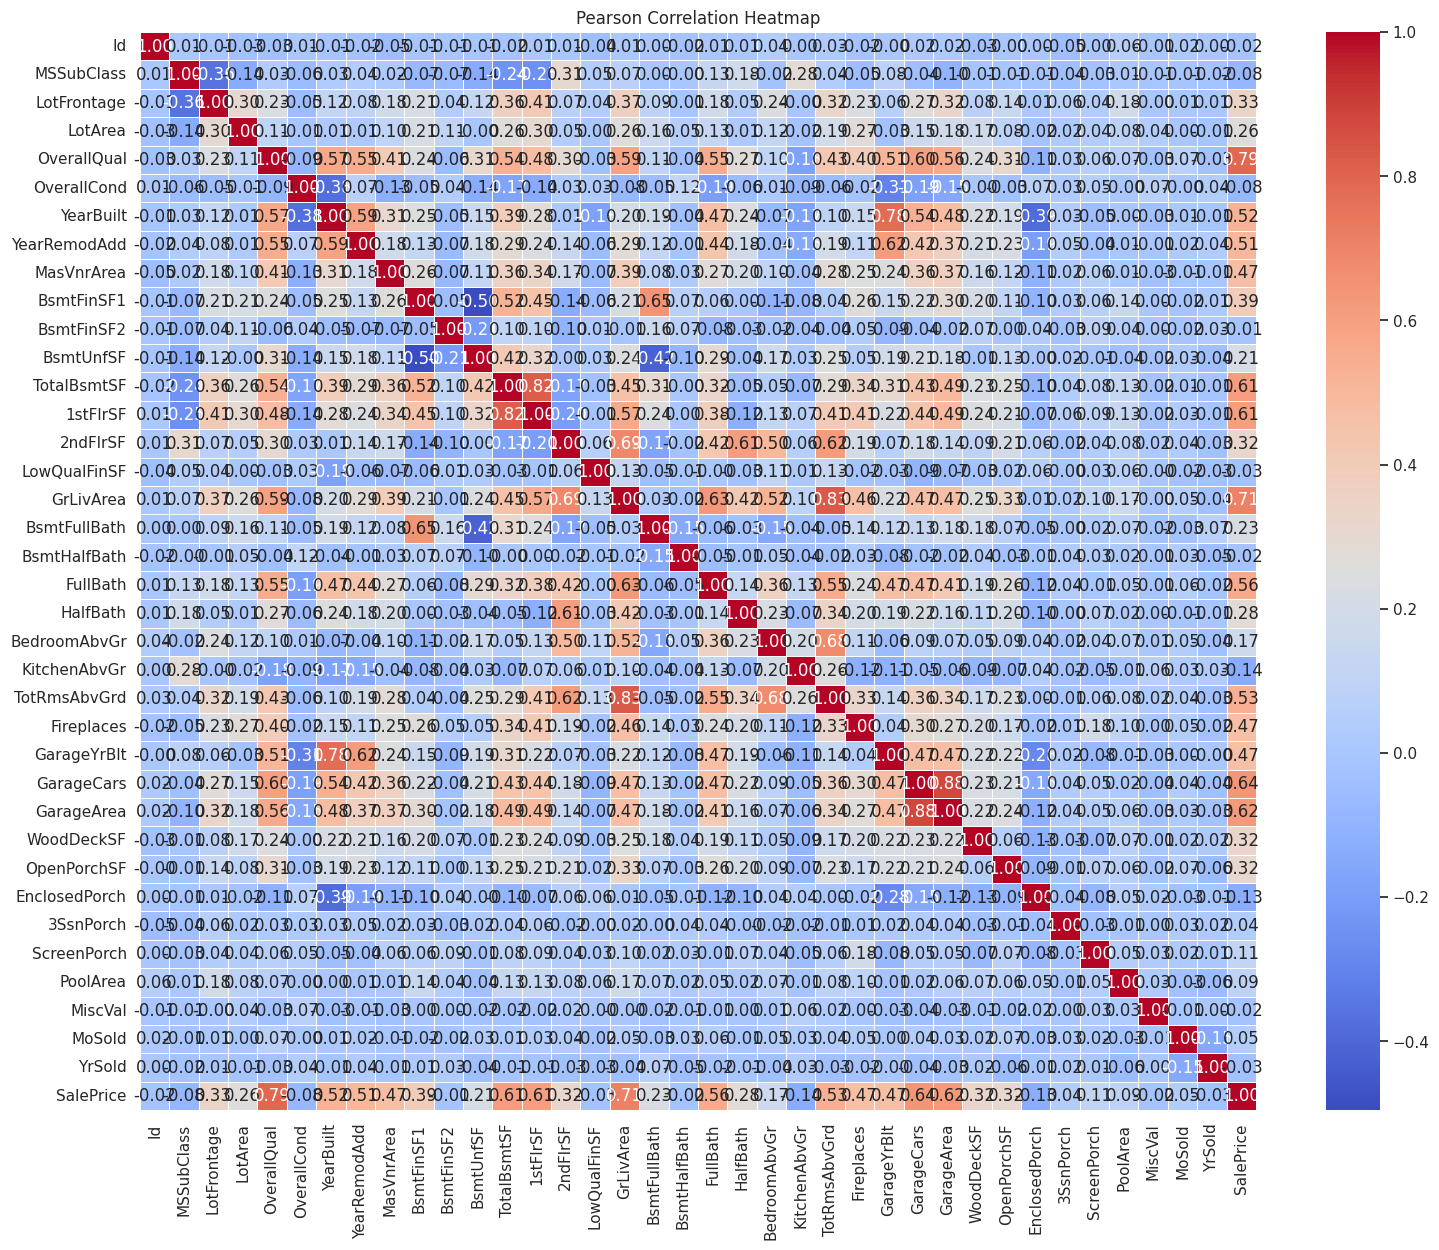

In [37]:
plt.figure(figsize=(18,14))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")

plt.show()

In [38]:
# Find highest correlated pair (excluding self-correlation)

corr_matrix = pearson_corr.abs()

np.fill_diagonal(corr_matrix.values, 0)

highest_corr = corr_matrix.unstack().sort_values(ascending=False)

highest_corr = highest_corr[highest_corr.index.get_level_values(0) != highest_corr.index.get_level_values(1)]

highest_pair = highest_corr.index[0]
highest_value = highest_corr.iloc[0]

print("Highest Correlated Pair:")
print(f"{highest_pair[0]} ↔ {highest_pair[1]}")
print(f"Correlation: {highest_value:.4f}")

Highest Correlated Pair:
GarageCars ↔ GarageArea
Correlation: 0.8825


## 9(a). Mean vs Median Imputation Strategy

For the two most skewed numerical features, the mean and median are compared. The median is generally preferred for highly skewed distributions because it is less influenced by extreme values.

In [39]:
# Two most skewed numeric columns
top2_skewed = skewness.index[:2]

print("Top Two Skewed Columns:")
print(top2_skewed)

Top Two Skewed Columns:
Index(['MiscVal', 'PoolArea'], dtype='object')


In [40]:
comparison = pd.DataFrame(columns=["Mean", "Median"])

for col in top2_skewed:
    comparison.loc[col] = [
        cleaned_df[col].mean(),
        cleaned_df[col].median()
    ]

comparison

,Mean,Median
MiscVal,43.489041,0.0
PoolArea,2.758904,0.0


In [41]:
for col in top2_skewed:
    if cleaned_df[col].isnull().sum() > 0:
        cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].median())

print(cleaned_df[top2_skewed].isnull().sum())

MiscVal     0
PoolArea    0
dtype: int64


## 9(b). Spearman Rank Correlation

Spearman correlation measures monotonic relationships between variables. It is compared with the Pearson correlation to identify relationships that may be non-linear but still consistently increasing or decreasing.

In [42]:
spearman_corr = cleaned_df.select_dtypes(include=['int64','float64']).corr(method='spearman')

spearman_corr

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.019226,-0.032951,-0.005364,-0.028771,0.003622,-0.005130,-0.011680,-0.036547,-0.013038,-0.006736,-0.009509,-0.033187,-0.000616,0.009455,-0.028463,0.002812,0.004662,-0.021475,0.007269,0.002564,0.041650,0.007574,0.025888,-0.013644,-0.003242,0.013301,0.006505,-0.043239,-0.003225,-0.006758,-0.036706,0.005962,0.055555,-0.043383,0.019018,0.001526,-0.018546
MSSubClass,0.019226,1.000000,-0.280102,-0.269570,0.108065,-0.071770,0.035848,0.006802,0.025821,-0.107629,-0.083871,-0.117603,-0.318897,-0.278318,0.487749,0.075794,0.203576,-0.042017,0.002480,0.194912,0.282632,0.068763,0.277162,0.165825,0.019480,0.080487,0.024226,-0.047133,0.023370,0.031900,0.011023,-0.035830,-0.021673,0.033250,-0.032840,0.018403,-0.027401,0.007192
LotFrontage,-0.032951,-0.280102,1.000000,0.554082,0.230305,-0.072772,0.185331,0.101659,0.242800,0.150312,0.052350,0.097988,0.352150,0.384900,0.045055,-0.034600,0.329049,0.078139,0.000334,0.193805,0.093098,0.291727,-0.005666,0.319740,0.212638,0.094418,0.325207,0.343772,0.101321,0.152614,-0.099960,0.052856,0.039848,0.076728,0.022408,0.022914,0.001682,0.375590
LotArea,-0.005364,-0.269570,0.554082,1.000000,0.233303,-0.046912,0.103385,0.075158,0.175909,0.171995,0.072019,0.077830,0.366197,0.443858,0.119356,-0.020255,0.449040,0.095609,0.045970,0.235377,0.142658,0.337788,-0.022752,0.405924,0.350198,0.037090,0.340195,0.367153,0.184285,0.176965,-0.066563,0.062282,0.092316,0.084460,0.059297,0.006423,-0.027473,0.456461
OverallQual,-0.028771,0.108065,0.230305,0.233303,1.000000,-0.177521,0.647392,0.557723,0.408136,0.132957,-0.117560,0.272939,0.459915,0.408730,0.289561,-0.034029,0.603262,0.098034,-0.050598,0.576372,0.298455,0.121517,-0.192439,0.427806,0.420626,0.592010,0.608756,0.541552,0.259439,0.435046,-0.162434,0.032903,0.046335,0.056667,-0.088019,0.061455,-0.025464,0.809829
OverallCond,0.003622,-0.071770,-0.072772,-0.046912,-0.177521,1.000000,-0.416964,-0.041464,-0.175895,-0.011087,0.102471,-0.128270,-0.217375,-0.166686,0.001111,0.039556,-0.153720,-0.052676,0.116015,-0.262400,-0.071342,-0.003713,-0.099754,-0.104919,-0.045383,-0.363105,-0.254763,-0.200718,-0.042662,-0.133284,0.109749,0.032384,0.074728,-0.005605,0.086625,-0.007203,0.050214,-0.129325
YearBuilt,-0.005130,0.035848,0.185331,0.103385,0.647392,-0.416964,1.000000,0.684388,0.395589,0.189645,-0.111692,0.139014,0.427187,0.293363,0.029716,-0.145936,0.288493,0.162080,-0.066313,0.537420,0.244901,-0.035257,-0.155604,0.176820,0.174655,0.845595,0.601519,0.528281,0.287729,0.392691,-0.408622,0.022498,-0.073119,0.008986,-0.091786,0.018621,-0.014100,0.652682
YearRemodAdd,-0.011680,0.006802,0.101659,0.075158,0.557723,-0.041464,0.684388,1.000000,0.229194,0.063353,-0.126086,0.176921,0.299042,0.240265,0.073049,-0.064542,0.282400,0.099904,-0.031495,0.431390,0.151562,-0.054371,-0.154208,0.198243,0.119270,0.696474,0.456245,0.398267,0.230241,0.353325,-0.235037,0.051694,-0.045808,0.002821,-0.090868,0.021081,0.045158,0.571159
MasVnrArea,-0.036547,0.025821,0.242800,0.175909,0.408136,-0.175895,0.395589,0.229194,1.000000,0.237541,-0.059622,0.074779,0.355855,0.348863,0.062473,-0.106269,0.318580,0.117518,0.033883,0.285716,0.165516,0.112684,-0.050639,0.261810,0.253522,0.288734,0.398213,0.360858,0.174173,0.204573,-0.178764,0.041525,0.039308,0.005148,-0.049343,0.016964,0.000322,0.415906
BsmtFinSF1,-0.013038,-0.107629,0.150312,0.171995,0.132957,-0.011087,0.189645,0.063353,0.237541,1.000000,0.050398,-0.573638,0.410413,0.323478,-0.191236,-0.079054,0.057471,0.674175,0.090712,0.011986,-0.013907,-0.084164,-0.106369,-0.050062,0.192264,0.071179,0.181381,0.244161,0.179359,0.081420,-0.148339,0.046802,0.

In [43]:
difference = (spearman_corr - pearson_corr).abs()

difference

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,0.000000,0.008069,0.023030,0.027861,0.000406,0.008987,0.007583,0.010318,0.014525,0.008014,0.000768,0.001569,0.017773,0.011113,0.003865,0.015767,0.005460,0.002373,0.001321,0.001681,0.004220,0.003931,0.004623,0.001351,0.006128,0.003120,0.003269,0.011129,0.013595,0.002748,0.009647,0.009929,0.004632,0.001489,0.037140,0.002154,0.000815,0.003371
MSSubClass,0.008069,0.000000,0.076616,0.129789,0.075438,0.012454,0.007998,0.033779,0.002248,0.037793,0.018222,0.023156,0.080378,0.026559,0.179863,0.029320,0.128723,0.045508,0.004813,0.063304,0.105278,0.092201,0.004559,0.125445,0.065049,0.000909,0.064336,0.051539,0.035949,0.038001,0.023060,0.007994,0.004358,0.024967,0.025156,0.031988,0.005994,0.091476
LotFrontage,0.023030,0.076616,0.000000,0.249559,0.004508,0.019491,0.068646,0.018311,0.064332,0.064054,0.009887,0.026110,0.011322,0.028872,0.027333,0.072069,0.038959,0.012204,0.007313,0.013271,0.045876,0.054887,0.000761,0.000777,0.020583,0.031422,0.055668,0.020261,0.025779,0.015601,0.110247,0.009089,0.002193,0.104091,0.022663,0.012464,0.004699,0.040819
LotArea,0.027861,0.129789,0.249559,0.000000,0.127498,0.041275,0.089157,0.061370,0.072588,0.042108,0.039151,0.080448,0.105363,0.144383,0.068370,0.025034,0.185923,0.062545,0.002076,0.109346,0.128399,0.218098,0.004968,0.215909,0.078834,0.062955,0.185325,0.186751,0.012588,0.092191,0.048223,0.041859,0.049155,0.006787,0.021230,0.005218,0.013212,0.192617
OverallQual,0.000406,0.075438,0.004508,0.127498,0.000000,0.085588,0.075069,0.007039,0.000884,0.106709,0.058442,0.035220,0.077893,0.067494,0.005932,0.003600,0.010255,0.013064,0.010448,0.025772,0.024996,0.019841,0.008556,0.000354,0.023861,0.077779,0.008085,0.020469,0.020516,0.126227,0.048497,0.002532,0.018551,0.008499,0.056613,0.009360,0.001882,0.018847
OverallCond,0.008987,0.012454,0.019491,0.041275,0.085588,0.000000,0.040981,0.115205,0.050202,0.035144,0.062242,0.008571,0.046278,0.022483,0.027831,0.014062,0.074034,0.002266,0.001806,0.068250,0.010572,0.016693,0.012753,0.047336,0.021563,0.056830,0.069005,0.049197,0.039328,0.100695,0.039393,0.006880,0.019917,0.003620,0.017848,0.003692,0.006264,0.051469
YearBuilt,0.007583,0.007998,0.068646,0.089157,0.075069,0.040981,0.000000,0.091533,0.083988,0.059858,0.062586,0.010026,0.035735,0.011377,0.019408,0.037848,0.089483,0.025518,0.028151,0.069149,0.002245,0.035394,0.019196,0.081231,0.026938,0.068413,0.063669,0.049328,0.062849,0.204005,0.021354,0.008857,0.022754,0.004036,0.057403,0.006223,0.000482,0.129784
YearRemodAdd,0.010318,0.033779,0.018311,0.061370,0.007039,0.115205,0.091533,0.000000,0.052665,0.065098,0.058328,0.004212,0.007977,0.000114,0.066975,0.002123,0.004988,0.019566,0.019158,0.007657,0.031768,0.013790,0.004611,0.006503,0.006689,0.080029,0.035623,0.026667,0.024515,0.127027,0.041118,0.006409,0.007068,0.003008,0.080582,0.000409,0.009415,0.064058
MasVnrArea,0.014525,0.002248,0.064332,0.072588,0.000884,0.050202,0.083988,0.052665,0.000000,0.023715,0.011707,0.039083,0.004212,0.009012,0.111327,0.037641,0.069472,0.034507,0.006480,0.012717,0.033591,0.009909,0.012189,0.017758,0.006506,0.044290,0.036269,0.010026,0.014182,0.082045,0.068858,0.022381,0.022940,0.006781,0.019831,0.023687,0.008639,0.056708
BsmtFinSF1,0.008014,0.037793,0.064054,0.042108,0.106709,0.035144,0.059858,0.065098,0.023715,0.000000,0.100515,0.078386,0.111983,0.122385,0.054157,0.014552,0.150700,0.024963,0.023294,0.046558,0.018170,0.023191,0.025362,0.094378,0.067747,0.077603,0.042673,0.052809,0.024947,0.030340,0.046036,0.020351,0.009969,0.082905,0.001526,0.000678,0.006434,0.084549


In [44]:
diff_matrix = difference.copy()

np.fill_diagonal(diff_matrix.values, 0)

top_differences = (
    diff_matrix.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)

# Remove duplicate pairs like (A,B) and (B,A)
seen = set()
rows = []

for (col1, col2), value in top_differences.items():
    pair = tuple(sorted([col1, col2]))
    if col1 != col2 and pair not in seen:
        seen.add(pair)
        rows.append((col1, col2, value))
    if len(rows) == 3:
        break

difference_table = pd.DataFrame(
    rows,
    columns=["Column 1", "Column 2", "|Spearman - Pearson|"]
)

difference_table

,Column 1,Column 2,|Spearman - Pearson|
0,LotFrontage,LotArea,0.249559
1,LotArea,BedroomAbvGr,0.218098
2,LotArea,TotRmsAbvGrd,0.215909


## 9(c). Grouped Aggregation

Grouped aggregation summarizes the distribution of SalePrice across different neighborhoods by computing the mean, standard deviation, and count.

In [45]:
group_stats = cleaned_df.groupby("Neighborhood")["SalePrice"].agg(
    ["mean", "std", "count"]
)

group_stats

,mean,std,count
Neighborhood,,,
Blmngtn,194870.882353,30393.229219,17
Blueste,137500.000000,19091.883092,2
BrDale,104493.750000,14330.176493,16
BrkSide,124834.051724,40348.689270,58
ClearCr,212565.428571,50231.538993,28
CollgCr,197965.773333,51403.666438,150
Crawfor,210624.725490,68866.395472,51
Edwards,128219.700000,43208.616459,100
Gilbert,192854.506329,35986.779085,79


In [46]:
highest_mean = group_stats["mean"].idxmax()

print("Highest Mean Group:", highest_mean)

Highest Mean Group: NoRidge


In [47]:
highest_std = group_stats["std"].idxmax()

print("Highest Std Group:", highest_std)

Highest Std Group: NoRidge


In [48]:
ratio = group_stats["mean"].max() / group_stats["mean"].min()

print("Ratio:", ratio)

Ratio: 3.4013727116863004


In [49]:
cleaned_df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv saved successfully.")

cleaned_data.csv saved successfully.


In [50]:
highest_mean

'NoRidge'

In [51]:
highest_std

'NoRidge'

In [52]:
ratio

3.4013727116863004